# Pattern Association with a Linear Associator

A linear associator that learns to map input vectors to output vectors. Explores single-pair and multiple associations, discrimination between patterns, and how the cosine between vectors reflects recall quality.

## LIBRARIES

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Single Pair Association

In [2]:
np.random.seed(42)

In [3]:
def generate_randvec_normalized(d): # d is the dimension of the vector
  randvec_zeromean = np.random.rand(d) - 0.5
  randvec_normalized = randvec_zeromean / np.sqrt(np.sum(randvec_zeromean**2))
  return randvec_normalized

In [4]:
f = generate_randvec_normalized(100)
g = generate_randvec_normalized(100)

In [5]:
A = np.outer(g,f)
print(A)

[[ 0.00677542 -0.02434068 -0.01252876 ...  0.00391312  0.02562959
   0.0211757 ]
 [-0.00197246  0.00708606  0.00364737 ... -0.00113919 -0.00746129
  -0.00616467]
 [ 0.00268437 -0.00964358 -0.00496379 ...  0.00155035  0.01015424
   0.00838964]
 ...
 [-0.00574212  0.02062854  0.01061803 ... -0.00331634 -0.02172088
  -0.01794624]
 [-0.00559718  0.02010784  0.01035001 ... -0.00323263 -0.0211726
  -0.01749325]
 [-0.00404693  0.01453859  0.00748338 ... -0.00233729 -0.01530845
  -0.01264816]]


In [6]:
g_prime = A @ f
print(g_prime)

[-0.16066199  0.04677194 -0.063653    0.00293869  0.13974503 -0.08596184
 -0.0307276   0.08762252 -0.09298878 -0.14504371 -0.07208932 -0.11615931
  0.14733329  0.10564728  0.04574103  0.12736516  0.10412206 -0.10746781
  0.13459931  0.01348954  0.10541405  0.13581046 -0.06240236 -0.13370409
 -0.09328468 -0.02499304  0.10903984  0.12368609 -0.1690546   0.003685
 -0.02831784 -0.09528274 -0.13033929 -0.05567797  0.15186339 -0.06061959
  0.00644287  0.06961046 -0.04675822  0.16176306  0.15856238 -0.08510805
 -0.00094342 -0.06827418 -0.07377317 -0.15879065  0.03756705  0.00091857
 -0.15378746 -0.07589696  0.13998484 -0.08929815 -0.12175726 -0.0036164
  0.1665182  -0.08844322  0.05902126  0.08970326 -0.08995796  0.07825006
 -0.04533408  0.04536458  0.04578422  0.0122663  -0.14048007  0.1149674
 -0.06145033 -0.10748548 -0.15745748  0.03116507  0.06088267 -0.16575075
  0.00414643 -0.09377821  0.04977636 -0.11165215  0.06546809 -0.0388358
  0.14974451 -0.1242856  -0.05449464 -0.1325309   0.1456

In [7]:
cosine = np.dot(g,g_prime)
g_prime_length = np.sqrt(np.sum(g_prime**2))

print('Cosine value between g and g\': ',cosine)
print('Length of g\': ',g_prime_length)

Cosine value between g and g':  1.0000000000000007
Length of g':  1.0000000000000004


**ANALYSIS**

The cosine between $g$ and $g′$, and the length of $g′$ is printed in the cell above. This is so because, as the prompt explained, $f^Tf = 1$, so $g$ should be identical to g'.
$$g' = Af = (gf^T)f = g(f^Tf) = g(1) = g$$

Since $g' = g$, we know the angle between $g$ and $g'$ should be $0$ (therefore, $cosine = 1$), and the length should be the same (both $1$, because $g$ is normalized).

## Discrimination

In [8]:
f_prime = generate_randvec_normalized(100)

In [9]:
cosine_f = np.dot(f,f_prime)
print('Cosine between f and f\': ',cosine_f)

Cosine between f and f':  -0.043428478313187246


In [10]:
Af_prime = A @ f_prime
Af_prime_length = np.sqrt(np.sum(Af_prime**2))
print('Length of A*f\': ',Af_prime_length)
print('Length of A*f: ',g_prime_length)

Length of A*f':  0.043428478313187246
Length of A*f:  1.0000000000000004


**ANALYSIS**

The cosine between $f$ and $f'$ is printed 2 cells above. This is consistent with my findings from HW1. In HW1, we discovered that the higher the dimension, the likely two vectors are going to be orthogonal. Therefore, having a dot product nearly $0$.

The length of $Af'$ and the length of $Af$, which is also $g'$, is very different.
$$Af' = (gf^T)f' = g(f^T f')$$
$f^T f'$ is what we calculated above: the cosine between f and f', as $f^T f'$ is also the dot product of the f and f', and f and f' are normalized vectors. Since $f^T f'$ is near $0$, the $Af'$ value is near $0$, whilst $Af$ is about $1$. This shows how selective the system is, only responding strongly to learned inputs.

## Multiple Associations

In [11]:
d = 100
num_pair_list = [1,20,40,60,80,100]
num_pair_first = 50

In [12]:
def vect_assoc_list_generator(num_pair, d=100):
  vect_assoc_list = []
  for i in range(num_pair):
    f = generate_randvec_normalized(d)
    g = generate_randvec_normalized(d)
    A = np.outer(g,f)
    vect_assoc_list.append([f,g,A])
  return vect_assoc_list

In [13]:
def new_matrix_generator(vect_assoc_list,num_pair, d=100):
  A_new = np.zeros((d,d))
  for i in range(num_pair):
    A_new = np.add(A_new, vect_assoc_list[i][2])
  return A_new

In [14]:
def matrix_tester(vect_assoc_list,A_new, num_pair, d=100):
  cosine_list = []
  g_prime_length_list = []
  h_prime_length_list = []
  test_result = {
      'cosine' : cosine_list,
      'g\' length' : g_prime_length_list,
      'h\' length' : h_prime_length_list
  }
  for i in range(num_pair):
    g_prime = A_new @ vect_assoc_list[i][0]
    cosine = np.dot(vect_assoc_list[i][1],g_prime)
    cosine_list.append(cosine)
    g_prime_length = np.sqrt(np.sum(g_prime**2))
    g_prime_length_list.append(g_prime_length)
    h = generate_randvec_normalized(d)
    h_prime = A_new @ h
    h_prime_length = np.sqrt(np.sum(h_prime**2))
    h_prime_length_list.append(h_prime_length)
  return test_result

In [15]:
def tester(num_pair, d=100):
  vect_assoc_list = vect_assoc_list_generator(num_pair=num_pair, d=d)
  A_new = new_matrix_generator(vect_assoc_list=vect_assoc_list, num_pair=num_pair, d=d)
  test_result = matrix_tester(vect_assoc_list=vect_assoc_list,A_new=A_new,num_pair=num_pair,d=d)
  return vect_assoc_list,A_new,test_result

For 50 Pairs


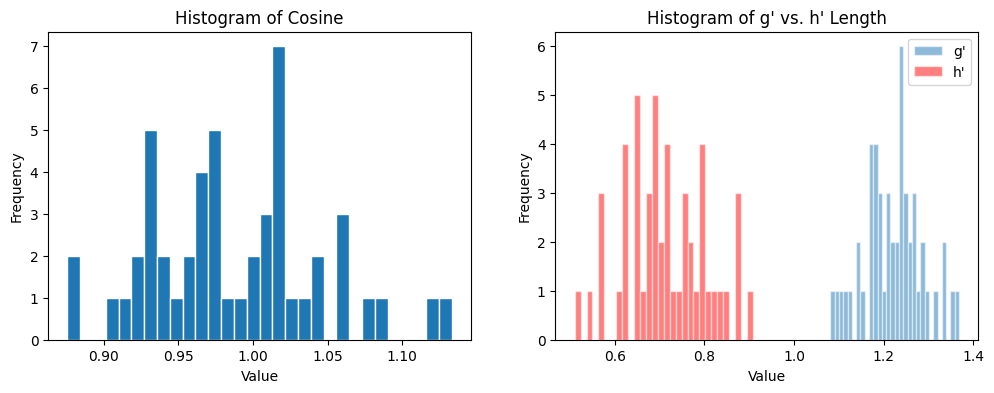

Mean cosine between g and g': 0.9878736553127574
Range of cosine between g and g': 0.8755450813819772 to 1.1330349543120857
Mean length of g': 1.2213920633962743
Mean length of h': 0.7116333349395945


In [16]:
print(f'For {num_pair_first} Pairs')
vect_list_50, A_50, results_50 = tester(num_pair_first, 100)

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.hist(results_50['cosine'], bins=30,edgecolor = 'white')
plt.title(f'Histogram of Cosine')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
plt.hist(results_50['g\' length'], bins=30,alpha=0.5, label='g\'',edgecolor = 'white')
plt.hist(results_50['h\' length'], bins=30, color='red',alpha=0.5, label='h\'', edgecolor='white',)
plt.title(f'Histogram of g\' vs. h\' Length')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()

plt.show()

print(f'Mean cosine between g and g\': {np.mean(results_50["cosine"])}')
print(f'Range of cosine between g and g\': {min(results_50["cosine"])} to {max(results_50["cosine"])}')
print(f'Mean length of g\': {np.mean(results_50["g\' length"])}')
print(f'Mean length of h\': {np.mean(results_50["h\' length"])}')

**ANALYSIS**

The mean cosine and the range of it is printed out in the cell above. While the calculation is more closer to a dot product between the two vectors, there are slight errors, such as going over 1, because cosine values cannot exceed 1. However, if we take consideration of the minor error in the length of g', which should be 1 in theory, we can know the cosine value is originally supposed to be around 1. The retrieval quality is pretty high, considering that most of the cosine values are close to 1.

The mean length of the retrieved $g'$ is printed out in the cell above. $$g'_i = g_i(f_i^T f_i) + \sum_{j \neq i} g_j(f_j^T f_i)$$
Because the input vectors used in this equation are normalized, it is likely to retrieve that property. It is more than 1, due to the noise.

For the new random vector h, the lengths of h' (=Ah) compared to the length of g' is different. h' is ~0.7, while g' is ~1.2. This shows the system is selective. That is, it only preserves the vector length and direction, when it is a certain vector that was used when amking the matrix A. The system selects the vectors that are known by the system previously.

Pairs | Cosine     | g'         | h'        
1     | 1.00000    | 1.00000    | 0.14693   
20    | 0.97388    | 1.05873    | 0.43779   
40    | 0.98012    | 1.15505    | 0.62026   
60    | 1.00371    | 1.26178    | 0.77904   
80    | 0.99497    | 1.31776    | 0.87450   
100   | 0.99121    | 1.38865    | 0.99315   


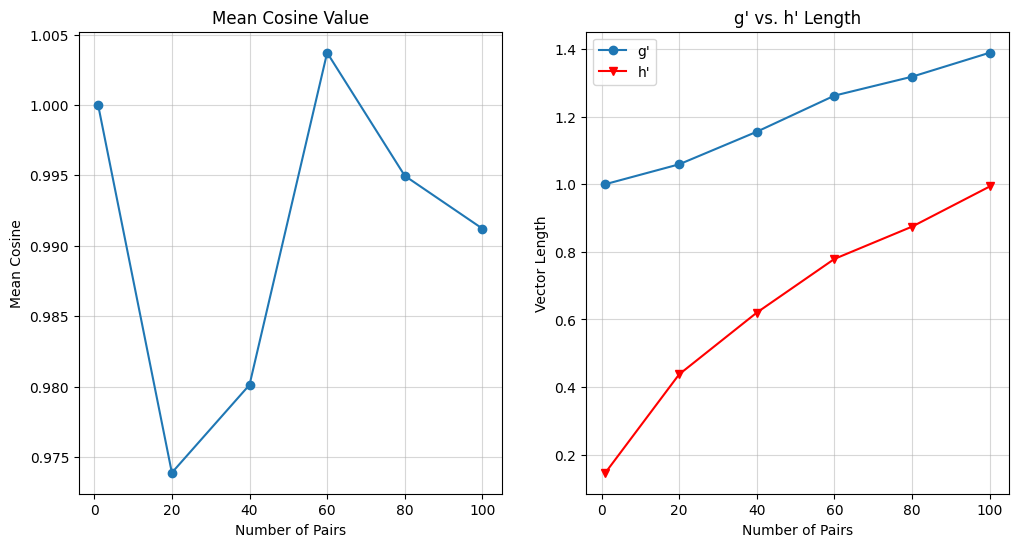

In [17]:
# Storage for the means
mean_cosines = []
mean_g_primes = []
mean_h_primes = []

print(f"{'Pairs':<5} | {'Cosine':<10} | {'g\'':<10} | {'h\'':<10}")

for k in num_pair_list:
    _, _, results = tester(k, 100)

    mean_cosine = np.mean(results['cosine'])
    mean_g_prime = np.mean(results['g\' length'])
    mean_h_prime = np.mean(results['h\' length'])

    mean_cosines.append(mean_cosine)
    mean_g_primes.append(mean_g_prime)
    mean_h_primes.append(mean_h_prime)

    print(f'{k:<5} | {mean_cosine:<10.5f} | {mean_g_prime:<10.5f} | {mean_h_prime:<10.5f}')

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(num_pair_list, mean_cosines,'o-')
plt.title('Mean Cosine Value')
plt.xlabel('Number of Pairs')
plt.ylabel('Mean Cosine')
plt.grid(True,alpha =0.5)

plt.subplot(1, 2, 2)
plt.plot(num_pair_list, mean_g_primes, 'o-',label='g\'')
plt.plot(num_pair_list, mean_h_primes, 'v-', color='red', label='h\'')
plt.title('g\' vs. h\' Length')
plt.xlabel('Number of Pairs')
plt.ylabel('Vector Length')
plt.legend()
plt.grid(True,alpha =0.5)

plt.show()

**ANALYSIS**

As I vary the number of stored pairs (1,20,40,60,80,100), the lengths of g' and h' increases. g' increases slowly. h' increases in a faster rate and reaches 1 at the end. The cosine value fluctuates around 1.

$$g'_i = g_i(f_i^T f_i) + \sum_{j \neq i} g_j(f_j^T f_i)$$
The first term of this equation, $g_i(f_i^T f_i)$ is $g_i$ because $(f_i^T f_i)$ comes to 1. This explains why the cosine value tends to be 1, which also means that the vectors g and g' have to same direction. The second term
$\sum_{j \neq i} g_j(f_j^T f_i)$ adds more random vectors as the number of stored values increase. This also means the noise value increases. Since, in the case of h', it relies mostly on the noise value, the overall h' length increases. This also happens in g' length.

## Computational Experiment

I am investigating option (a), about ablation or graceful degradation.

I vaired the number of pair of vectors, and the damage percentages.

I measured the mean cosine similarity between g and g' for each damage percentage and for the number of pairs to measure the retrieval quality.

In [25]:
d = 100
num_pair_list = [1, 20, 50, 80, 100, 150, 200, 250, 500, 1000] # number of pairs
damage_pct_list = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9] # damage percentage

In [26]:
def run_ablation(num_pair, damage_pct_list, d =100):
    print(f'Training network with {num_pair} pairs')
    vect_list = vect_assoc_list_generator(num_pair=num_pair, d=d)
    A_original = new_matrix_generator(vect_assoc_list=vect_list, num_pair=num_pair, d=d)

    mean_cosines = []

    print(f"{'Damage %':<10} | {'Mean Cosine':<15}")
    print('-' * 28)

    for damage_pct in damage_pct_list:
        A_damaged = A_original.copy() # to preserve original

        # ablation
        # False if we want the number to be destroyed
        mask = np.random.rand(d, d) > damage_pct
        A_damaged = A_damaged * mask

        current_cosines = []
        for i in range(num_pair):
            f = vect_list[i][0]
            g = vect_list[i][1]

            g_prime = A_damaged @ f
            g_prime_length = np.sqrt(np.sum(g_prime**2))

            if g_prime_length > 0:
                cos = np.dot(g, g_prime) / g_prime_length
            else:
                cos = 0
            current_cosines.append(cos)

        mean_cos = np.mean(current_cosines)
        mean_cosines.append(mean_cos)
        print(f"{damage_pct*100:<10.0f}% | {mean_cos:<15.4f}")

    plt.figure(figsize=(8, 5))
    plt.plot([x*100 for x in damage_pct_list], mean_cosines, 'o-', linewidth=2)
    plt.title(f'Performance under Ablation of {num_pair}')
    plt.xlabel('Percentage of Matrix Destroyed (%)')
    plt.ylabel('Retrieval Quality (Mean Cosine)')
    plt.grid(True)
    plt.ylim(0, 1.1)
    plt.show()

    return mean_cosines

Ablation Experiment
For 1 Pairs
Training network with 1 pairs
Damage %   | Mean Cosine    
----------------------------
0         % | 1.0000         
20        % | 0.9985         
40        % | 0.9941         
50        % | 0.9917         
60        % | 0.9852         
80        % | 0.9684         
90        % | 0.9322         


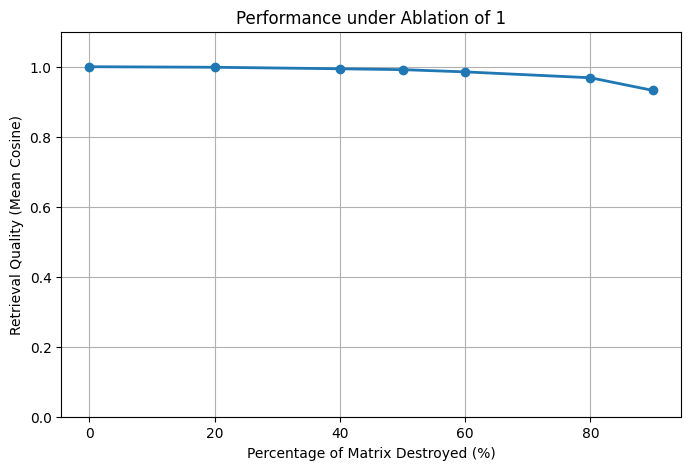

For 20 Pairs
Training network with 20 pairs
Damage %   | Mean Cosine    
----------------------------
0         % | 0.9256         
20        % | 0.9019         
40        % | 0.8756         
50        % | 0.8564         
60        % | 0.8273         
80        % | 0.7115         
90        % | 0.5704         


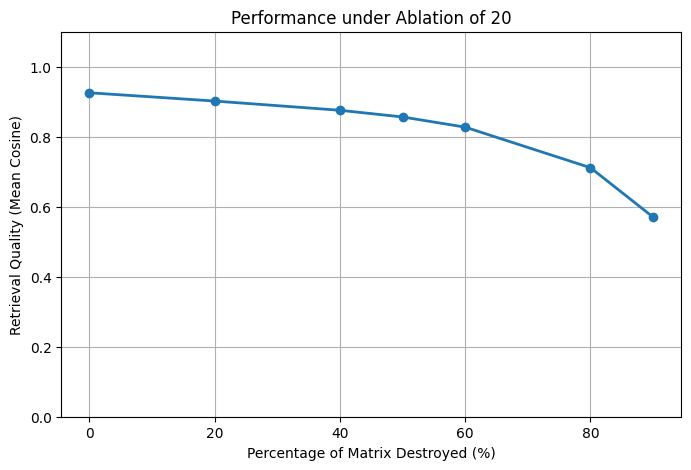

For 50 Pairs
Training network with 50 pairs
Damage %   | Mean Cosine    
----------------------------
0         % | 0.8258         
20        % | 0.7881         
40        % | 0.7395         
50        % | 0.7188         
60        % | 0.6704         
80        % | 0.5472         
90        % | 0.4001         


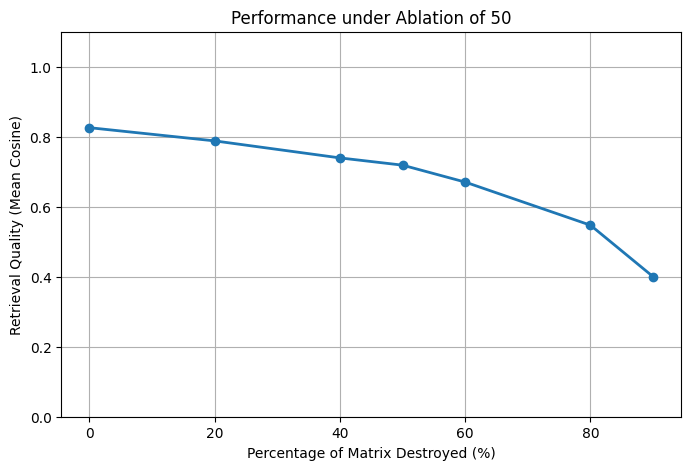

For 80 Pairs
Training network with 80 pairs
Damage %   | Mean Cosine    
----------------------------
0         % | 0.7539         
20        % | 0.7122         
40        % | 0.6611         
50        % | 0.6235         
60        % | 0.5846         
80        % | 0.4466         
90        % | 0.3225         


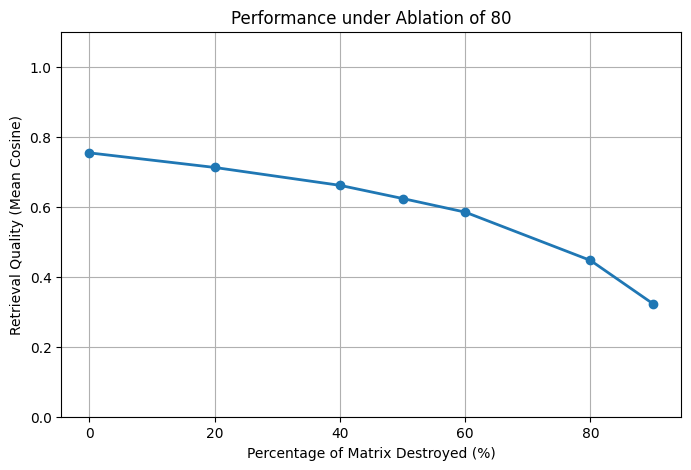

For 100 Pairs
Training network with 100 pairs
Damage %   | Mean Cosine    
----------------------------
0         % | 0.7067         
20        % | 0.6663         
40        % | 0.6170         
50        % | 0.5792         
60        % | 0.5303         
80        % | 0.4031         
90        % | 0.2973         


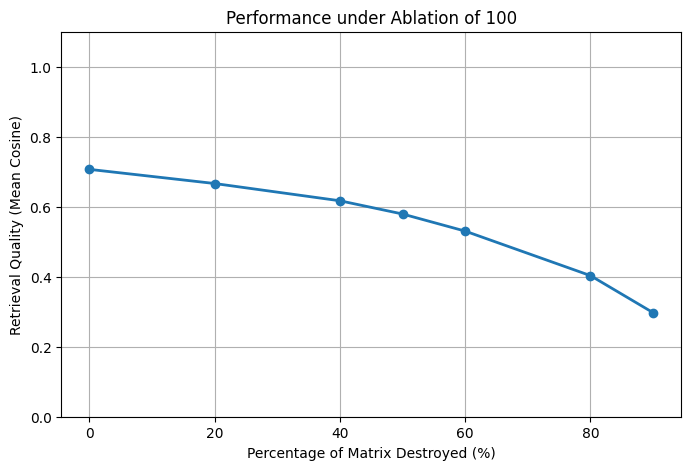

For 150 Pairs
Training network with 150 pairs
Damage %   | Mean Cosine    
----------------------------
0         % | 0.6413         
20        % | 0.5974         
40        % | 0.5439         
50        % | 0.4969         
60        % | 0.4689         
80        % | 0.3408         
90        % | 0.2358         


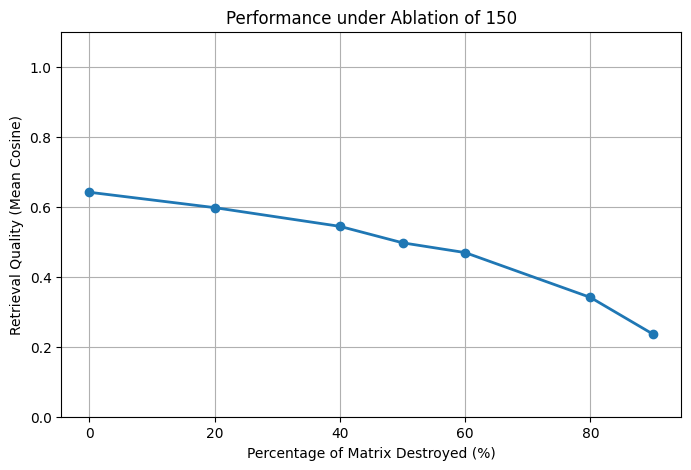

For 200 Pairs
Training network with 200 pairs
Damage %   | Mean Cosine    
----------------------------
0         % | 0.5806         
20        % | 0.5360         
40        % | 0.4781         
50        % | 0.4407         
60        % | 0.4075         
80        % | 0.3039         
90        % | 0.2195         


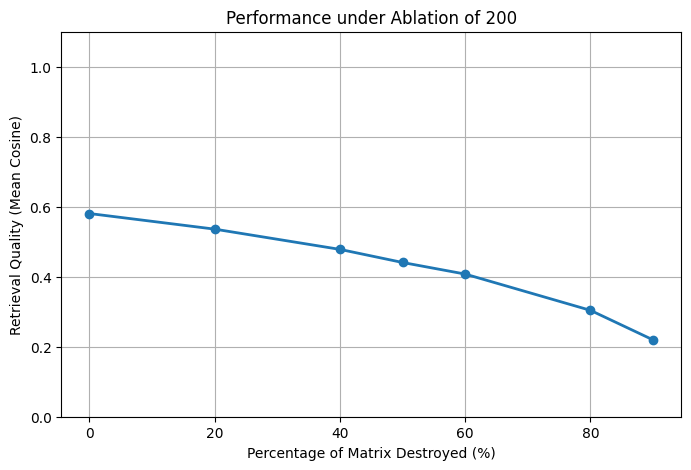

For 250 Pairs
Training network with 250 pairs
Damage %   | Mean Cosine    
----------------------------
0         % | 0.5383         
20        % | 0.4949         
40        % | 0.4442         
50        % | 0.4065         
60        % | 0.3754         
80        % | 0.2769         
90        % | 0.1998         


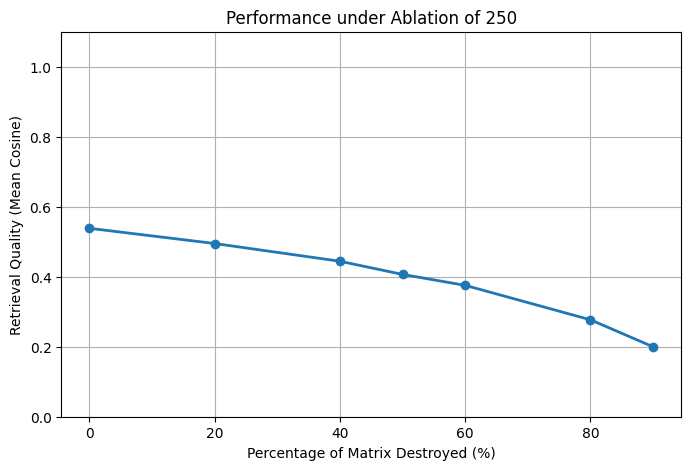

For 500 Pairs
Training network with 500 pairs
Damage %   | Mean Cosine    
----------------------------
0         % | 0.4111         
20        % | 0.3764         
40        % | 0.3320         
50        % | 0.3042         
60        % | 0.2743         
80        % | 0.1973         
90        % | 0.1369         


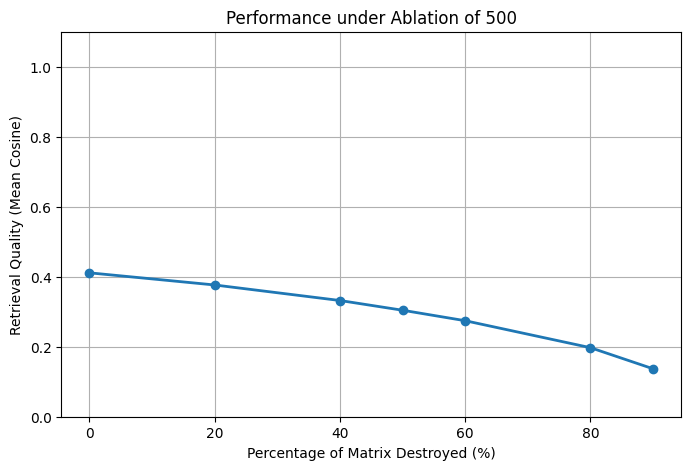

For 1000 Pairs
Training network with 1000 pairs
Damage %   | Mean Cosine    
----------------------------
0         % | 0.3008         
20        % | 0.2695         
40        % | 0.2359         
50        % | 0.2161         
60        % | 0.1986         
80        % | 0.1396         
90        % | 0.1039         


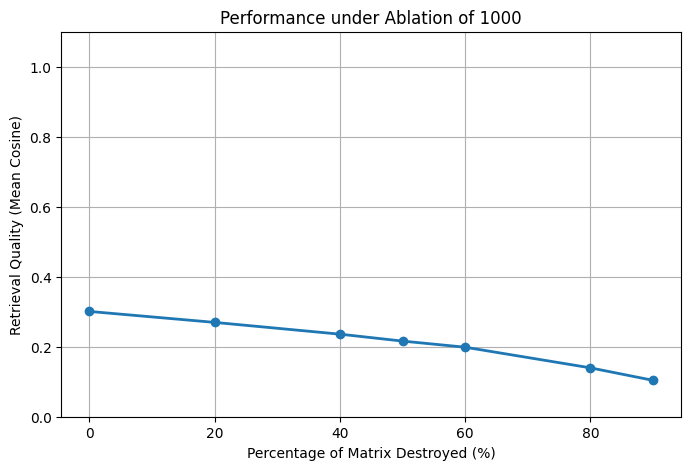

In [27]:
print('Ablation Experiment')
mean_cosines_total_list = []
for num_pair in num_pair_list:
  print(f'For {num_pair} Pairs')
  mean_cosines_per_pair = run_ablation(num_pair, damage_pct_list)
  mean_cosines_total_list.append(mean_cosines_per_pair)


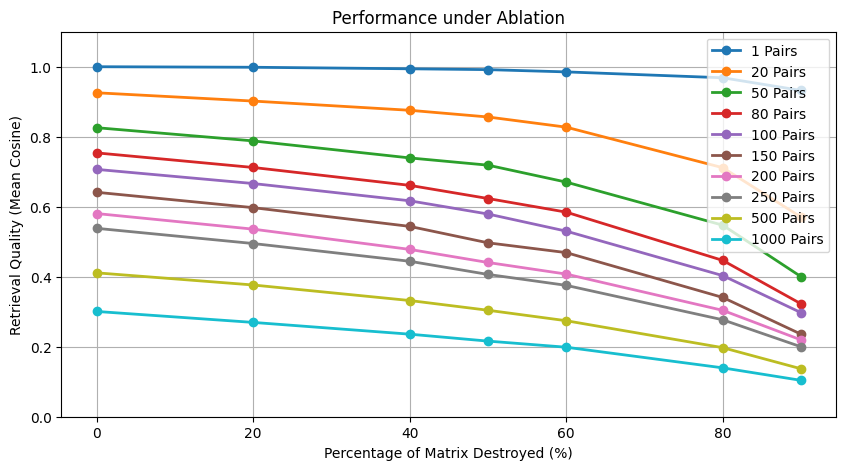

In [30]:
plt.figure(figsize=(10, 5))
for i, num_pair in enumerate(num_pair_list):
  plt.plot([x*100 for x in damage_pct_list], mean_cosines_total_list[i], 'o-', linewidth=2, label=f'{num_pair} Pairs')

plt.title(f'Performance under Ablation')
plt.xlabel('Percentage of Matrix Destroyed (%)')
plt.ylabel('Retrieval Quality (Mean Cosine)')
plt.grid(True)
plt.ylim(0, 1.1)
plt.legend()
plt.show()


**ANALYSIS**

The mean and graphs per each number of pairs are in the cells above.

The retrieval quality decreases as the percentage of matrix is more destroyed. It is also affected bt the number of pairs. As the more the number of pairs, the less the retrieval quality gets. However, the decrease happens slowly.

The system behaves as I observed because the linear associator uses a distributed memory system. This means the the memory is spread out through the many of the connections, making it able to retrieve some information in a graceful way.

The information is stored using the sum of the outer products, as we found out in the earlier problems. ($A = \sum g_i f_i^T$) So, each information is spread out across the 100x100 weights in the matrix. That means, all weights ared responsible for a very small part of a single memory. So, even though we remove random weights and make them a 0, it is still likely that it will tend to point to a certain direction, making the cosine value between the two vectors to not dramatically change and decrease in its value. However, if the damage percentage increases too much, it is definitely hard to retrieve the same quality of information as lower percentages.

The noise increases as there are more pairs, which is explained in the third problem.